In [1]:
import torch 
import torch.nn as nn

class GMSKAutoEncoder(nn.Module):
    def __init__(self):
        super(GMSKAutoEncoder, self).__init__()

        # Encoder : Compresses noisy I & Q stream into features
        self.encoder = nn.Sequential(
            # Input shape: (batch_size, 2, signal_length)
            nn.Conv1d(2, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )

        # Decoder : Reconstructs clean I & Q stream from features
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(32, 16, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.Conv1d(16, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(8, 2, kernel_size=3, padding=1), # Output shape: (batch_size, 2, signal_length)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [10]:
import torch.optim as optim
from pathlib import Path
import numpy as np

data_path = Path.cwd().parent / "Data"

# Load Data
X = torch.from_numpy(np.load(data_path / "X_noisy.npy")).float()  # Noisy signals
Y = torch.from_numpy(np.load(data_path / "Y_clean.npy")).float()  # Clean signals

# Setup model, loss & optimizer
model = GMSKAutoEncoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 50

# Training Loop
for epoch in range(num_epochs):
    optimizer.zero_grad()
    outputs = model(X)
    loss = criterion(outputs, Y)
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

save_path = Path.cwd().parent / "weights"
# Save the trained model
torch.save(model.state_dict(), save_path / "gmsk_denoiser.pth")

Epoch 0, Loss: 0.5188300013542175
Epoch 10, Loss: 0.49208366870880127
Epoch 20, Loss: 0.46247589588165283
Epoch 30, Loss: 0.41922271251678467
Epoch 40, Loss: 0.3798591196537018


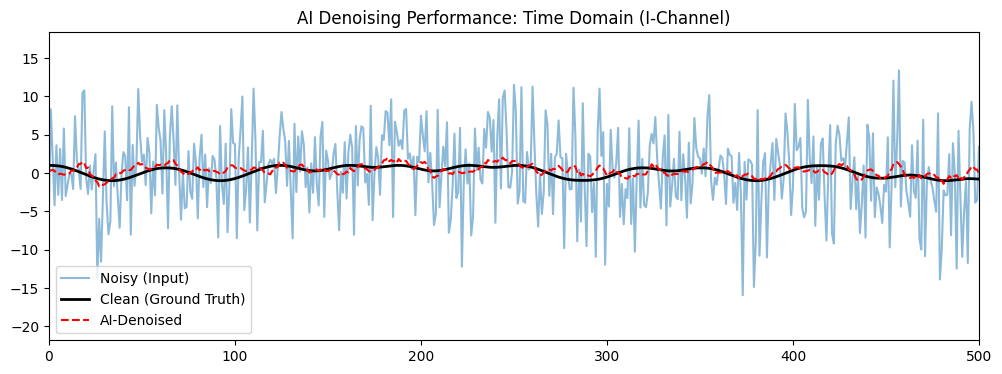

In [12]:
import matplotlib.pyplot as plt

# 1. Select a high-noise sample (e.g., SNR = 0dB)
sample_idx = 0 
noisy_input = X[sample_idx:sample_idx+1] # Shape: (1, 2, Length)

# 2. Run through the AI
model.eval()
with torch.no_grad():
    denoised_output = model(noisy_input).squeeze(0).numpy()

# 3. Plot I-channel comparison
plt.figure(figsize=(12, 4))
plt.plot(noisy_input[0, 0, :].numpy(), label='Noisy (Input)', alpha=0.5)
plt.plot(Y[sample_idx, 0, :].numpy(), label='Clean (Ground Truth)', color='black', lw=2)
plt.plot(denoised_output[0, :], label='AI-Denoised', color='red', linestyle='--')
plt.xlim(0, 500)
plt.title("AI Denoising Performance: Time Domain (I-Channel)")
plt.legend()
plt.show()

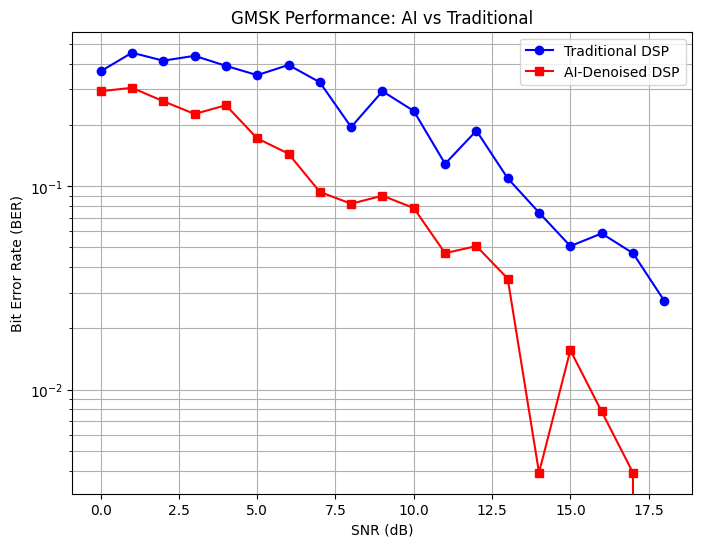

In [14]:
from src.demodulation import gmsk_demod
from src.test_gen import generate_test_signal
snr_range = np.arange(0, 19)  # SNRs from 0dB to 19dB
L = 8  # Samples per symbol
fc = 146e6  # Carrier frequency

ber_traditional = []
ber_ai_assisted = []

model.eval()

for snr in snr_range:
    # 1. Generate test data for this specific SNR
    # (Assuming you have a helper to generate bits and noisy signals)
    bits, s_noisy, s_clean = generate_test_signal(snr, L, fc)
    
    # --- Traditional Path ---
    bits_trad = gmsk_demod(s_noisy, L)
    err_trad = np.sum(bits != bits_trad) / len(bits)
    ber_traditional.append(err_trad)
    
    # --- AI Path ---
    # Prepare for model: (1, 2, Length)
    input_tensor = torch.from_numpy(np.vstack((s_noisy.real, s_noisy.imag))).float().unsqueeze(0)
    with torch.no_grad():
        denoised_iq_raw = model(input_tensor).squeeze(0).numpy()
    
    # Reconstruct complex signal from AI output
    s_denoised = denoised_iq_raw[0, :] + 1j * denoised_iq_raw[1, :]
    
    bits_ai = gmsk_demod(s_denoised, L)
    err_ai = np.sum(bits != bits_ai) / len(bits)
    ber_ai_assisted.append(err_ai)

# Plotting the Waterfall Curve
plt.figure(figsize=(8, 6))
plt.semilogy(snr_range, ber_traditional, 'b-o', label='Traditional DSP')
plt.semilogy(snr_range, ber_ai_assisted, 'r-s', label='AI-Denoised DSP')
plt.grid(True, which='both')
plt.xlabel('SNR (dB)')
plt.ylabel('Bit Error Rate (BER)')
plt.title('GMSK Performance: AI vs Traditional')
plt.legend()
plt.show()